In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder ,StandardScaler
from sklearn.linear_model import LinearRegression 
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import matplotlib.pyplot as plt
import pandas as pd
df= pd.read_csv('Train.csv')
df

,serial number,account_info,duration_month,credit_history,purpose,credit_amount,savings_account,employment_st,poi,personal_status,...,resident_since,property_type,age,installment_type,housing_type,credits_no,job_type,liables,telephone,foreigner
0,1,<0,6.0,A34,radio/TV,1169,unknown,A75,4,A93,...,4.0,A121,67.0,A143,A152,2,A173,1,yes,foreigner
1,2,0-199,48.0,A32,radio/TV,5951,<100,A73,2,A92,...,2.0,A121,22.0,A143,A152,1,A173,1,no,foreigner
2,3,unknown,12.0,A34,education,2096,<100,A74,2,A93,...,3.0,A121,49.0,A143,A152,1,A172,2,no,foreigner
3,4,<0,42.0,A32,furniture/equipment,7882,<100,A74,2,A93,...,4.0,A122,45.0,A143,A153,1,A173,2,no,foreigner
4,5,<0,24.0,A33,new_car,4870,<100,A73,3,A93,...,4.0,A124,53.0,A143,A153,2,A173,2,no,foreigner
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,796,?,9.0,A32,furniture/equipment,2301,100-499,A72,2,A92,...,4.0,A122,22.0,A143,A151,1,A173,1,no,foreigner
796,797,<0,18.0,A32,old_car,7511,unknown,A75,1,A93,...,4.0,A122,51.0,A143,A153,1,A173,2,yes,foreigner
797,798,unknown,12.0,A34,furniture/equipment,1258,<100,A72,2,A92,...,4.0,A122,22.0,A143,A151,2,A172,1,no,foreigner
798,799,unknown,24.0,A33,new_car,717,unknown,A75,4,A94,...,4.0,A123,54.0,A143,A152,2,A173,1,yes,foreigner


In [2]:
df.isnull().sum()

serial number        0
account_info         0
duration_month      28
credit_history       0
purpose              0
credit_amount        0
savings_account      0
employment_st        0
poi                  0
personal_status      0
gurantors            0
resident_since      13
property_type        0
age                 33
installment_type     0
housing_type         0
credits_no           0
job_type             0
liables              0
telephone            0
foreigner            0
dtype: int64

In [3]:
df.dropna(inplace=True)

In [4]:
df.isnull().sum()

serial number       0
account_info        0
duration_month      0
credit_history      0
purpose             0
credit_amount       0
savings_account     0
employment_st       0
poi                 0
personal_status     0
gurantors           0
resident_since      0
property_type       0
age                 0
installment_type    0
housing_type        0
credits_no          0
job_type            0
liables             0
telephone           0
foreigner           0
dtype: int64

In [5]:
df['account_info'].unique()

array(['<0', '0-199', 'unknown', '?', '>=200'], dtype=object)

In [6]:
df['account_info'].replace('<0',0,inplace=True)
df['account_info'].replace('0-199',1,inplace=True)
df['account_info'].replace('unknown',0,inplace=True)
df['account_info'].replace('?',0,inplace=True)
df['account_info'].replace('>=200',0,inplace=True)






C:\Users\ahile\AppData\Local\Temp\ipykernel_2492\643458387.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['account_info'].replace('<0',0,inplace=True)
C:\Users\ahile\AppData\Local\Temp\ipykernel_2492\643458387.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

In [7]:
for i in df.columns:
  print(df[i])
  print(df[i].unique())

0        1
1        2
2        3
3        4
4        5
      ... 
794    795
795    796
796    797
797    798
798    799
Name: serial number, Length: 729, dtype: int64
[  1   2   3   4   5   7   9  10  11  12  13  14  15  16  17  18  19  20
  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38
  39  40  41  42  43  44  45  47  48  49  50  51  52  53  54  55  56  57
  58  59  60  61  62  63  64  65  67  68  69  70  71  72  73  74  75  76
  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94
  95  96  97  98  99 101 103 105 106 107 108 109 111 112 113 114 116 117
 118 119 120 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136
 137 138 140 141 142 143 144 146 147 148 149 150 151 152 153 154 155 156
 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174
 176 177 179 181 182 184 185 186 187 188 189 190 191 192 193 194 195 196
 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214
 215 216 217 218 219 220 221 

In [8]:
df['foreigner'].replace('?','unknown',inplace=True)

C:\Users\ahile\AppData\Local\Temp\ipykernel_2492\454243558.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['foreigner'].replace('?','unknown',inplace=True)


In [9]:
df['telephone'].replace('?','unknown',inplace=True)

C:\Users\ahile\AppData\Local\Temp\ipykernel_2492\3802268524.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['telephone'].replace('?','unknown',inplace=True)


In [10]:
df['gurantors'].replace('?','unknown',inplace=True)

C:\Users\ahile\AppData\Local\Temp\ipykernel_2492\2526047814.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['gurantors'].replace('?','unknown',inplace=True)


In [11]:
df['savings_account'].unique()

array(['unknown', '<100', '500-999', '>=1000', '100-499'], dtype=object)

In [12]:
df['savings_account'].replace('<100',1,inplace=True)
df['savings_account'].replace('500-999',4,inplace=True)
df['savings_account'].replace('unknown',0,inplace=True)
df['savings_account'].replace('',0,inplace=True)
df['savings_account'].replace('>=1000',10,inplace=True)
df['savings_account'].replace('100-499',5,inplace=True)



C:\Users\ahile\AppData\Local\Temp\ipykernel_2492\2097138957.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['savings_account'].replace('<100',1,inplace=True)
C:\Users\ahile\AppData\Local\Temp\ipykernel_2492\2097138957.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [13]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='credit_amount'>

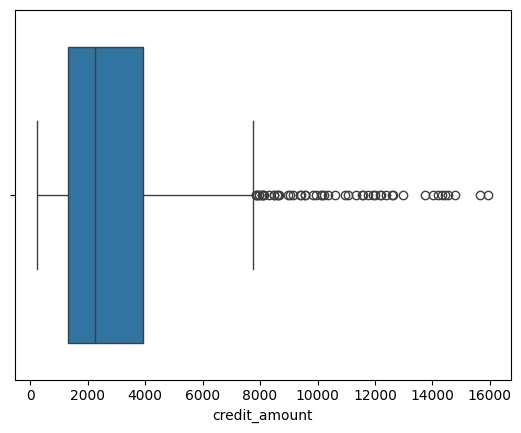

In [14]:
sns.boxplot(x='credit_amount',data=df)

<Axes: >

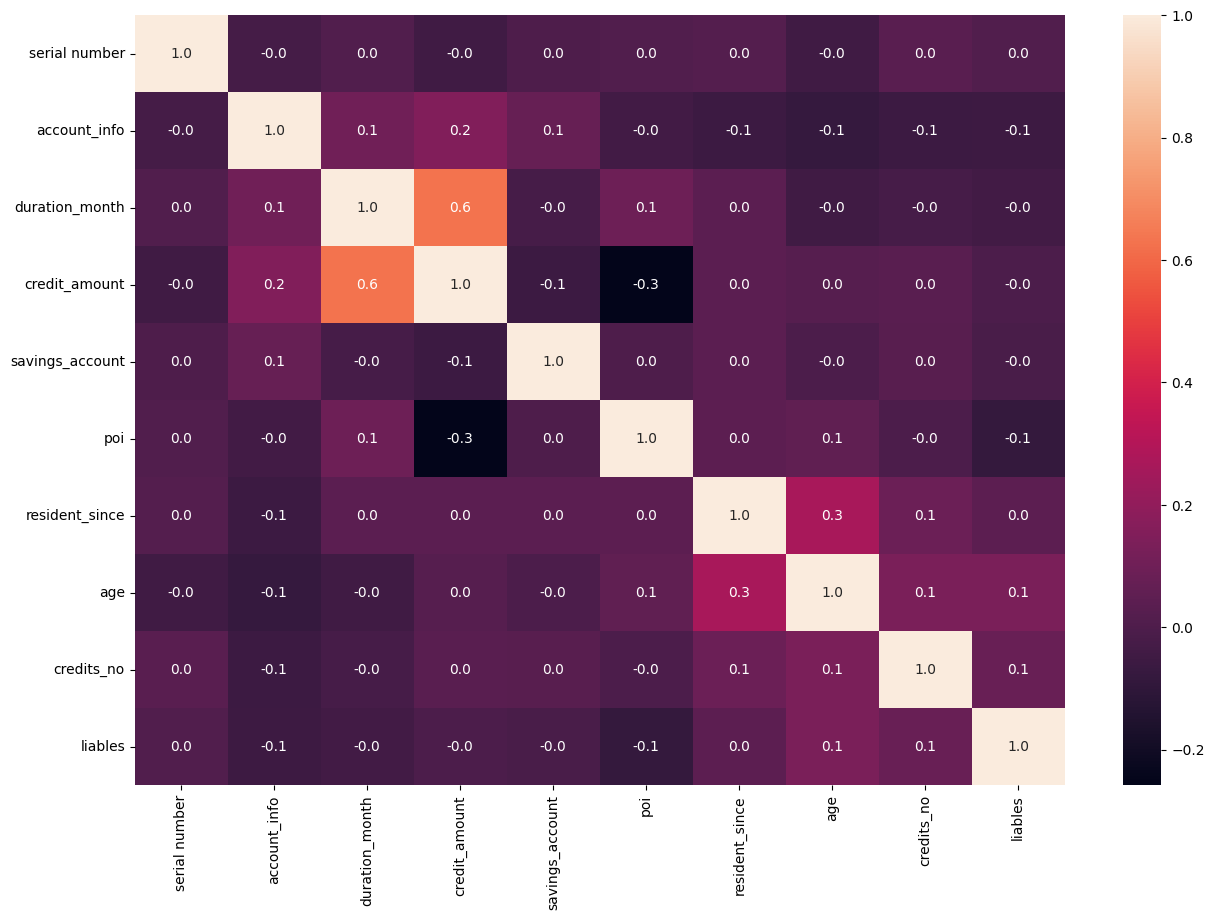

In [15]:
plt.figure(figsize=(15,10))
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True,fmt='.1f')

In [16]:
df['account_info'].dtype

dtype('int64')

In [17]:
#Q1 = df.credit_amount.quantile(.25)
#Q3 = df.credit_amount.quantile(.75)
#Q1, Q3

#IQR = Q3 - Q1
#IQR

#LL = Q1 - 1.5*IQR
#UL = Q3 + 1.5*IQR
#LL, UL

#df = df[~((df.credit_amount<LL)|(df.credit_amount>UL))] #to remove outliers
#df

In [18]:
df.drop(columns=['telephone'])

,serial number,account_info,duration_month,credit_history,purpose,credit_amount,savings_account,employment_st,poi,personal_status,gurantors,resident_since,property_type,age,installment_type,housing_type,credits_no,job_type,liables,foreigner
0,1,0,6.0,A34,radio/TV,1169,0,A75,4,A93,A101,4.0,A121,67.0,A143,A152,2,A173,1,foreigner
1,2,1,48.0,A32,radio/TV,5951,1,A73,2,A92,A101,2.0,A121,22.0,A143,A152,1,A173,1,foreigner
2,3,0,12.0,A34,education,2096,1,A74,2,A93,A101,3.0,A121,49.0,A143,A152,1,A172,2,foreigner
3,4,0,42.0,A32,furniture/equipment,7882,1,A74,2,A93,A103,4.0,A122,45.0,A143,A153,1,A173,2,foreigner
4,5,0,24.0,A33,new_car,4870,1,A73,3,A93,A101,4.0,A124,53.0,A143,A153,2,A173,2,foreigner
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
794,795,0,24.0,A32,furniture/equipment,3062,4,A75,4,A93,A101,3.0,A124,32.0,A143,A151,1,A173,1,foreigner
795,796,0,9.0,A32,furniture/equipment,2301,5,A72,2,A92,A101,4.0,A122,22.0,A143,A151,1,A173,1,foreigner
796,797,0,18.0,A32,old_car,7511,0,A75,1,A93,unknown,4.0,A122,51.0,A143,A153,1,A173,2,foreigner
797,798,0,12.0,A34,furniture/equipment,1258,1,A72,2,A92,A101,4.0,A122,22.0,A143,A151,2,A172,1,foreigner


In [19]:
for i in df.select_dtypes(include=['object']).columns:
  print(i)
  l=LabelEncoder() #calling a function
  df[i] = l.fit_transform(df[i]) #fit_transform to transform categorical values to numerical
df

credit_history
purpose
employment_st
personal_status
gurantors
property_type
installment_type
housing_type
job_type
telephone
foreigner


,serial number,account_info,duration_month,credit_history,purpose,credit_amount,savings_account,employment_st,poi,personal_status,...,resident_since,property_type,age,installment_type,housing_type,credits_no,job_type,liables,telephone,foreigner
0,1,0,6.0,4,7,1169,0,4,4,2,...,4.0,0,67.0,2,1,2,2,1,2,0
1,2,1,48.0,2,7,5951,1,2,2,1,...,2.0,0,22.0,2,1,1,2,1,0,0
2,3,0,12.0,4,2,2096,1,3,2,2,...,3.0,0,49.0,2,1,1,1,2,0,0
3,4,0,42.0,2,3,7882,1,3,2,2,...,4.0,1,45.0,2,2,1,2,2,0,0
4,5,0,24.0,3,4,4870,1,2,3,2,...,4.0,3,53.0,2,2,2,2,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
794,795,0,24.0,2,3,3062,4,4,4,2,...,3.0,3,32.0,2,0,1,2,1,2,0
795,796,0,9.0,2,3,2301,5,1,2,1,...,4.0,1,22.0,2,0,1,2,1,0,0
796,797,0,18.0,2,5,7511,0,4,1,2,...,4.0,1,51.0,2,2,1,2,2,2,0
797,798,0,12.0,4,3,1258,1,1,2,1,...,4.0,1,22.0,2,0,2,1,1,0,0


In [20]:
x = df.drop('credit_amount', axis=1) #independent columns
x
y = df['credit_amount']

x_train, x_test, y_train, y_test = train_test_split(x,y, train_size=0.8, random_state=42)

In [21]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression() #calling  a function
lin_reg.fit(x_train, y_train)
train = lin_reg.score(x_train, y_train)
print(train)

0.567659933792122


In [22]:
lin_reg_pred = lin_reg.predict(x_test)
print(lin_reg_pred)

lin_reg_mse = mean_squared_error(y_test, lin_reg_pred)

lin_reg_rmse = np.sqrt(lin_reg_mse)

lin_reg_mae = mean_absolute_error(y_test, lin_reg_pred)

print('Mean Squared Error:',lin_reg_mse)
print('Root Mean Squared Error:',lin_reg_rmse)
print('Mean Absolute Error:',lin_reg_mae)

[  409.61070173  3653.13621145   659.07528045  4042.49982349
  1795.78001135  3188.39258455  5284.19874921  2551.08757419
  5908.39244556  4095.69058033  2952.96906509  4785.6177539
  1767.16367617  2112.00651939   633.30480784   775.79466105
  3703.95490384  5104.11399921  9138.64886406  3533.79372115
  3221.73451717  4538.50229885  2128.24739661  4900.92413806
  1989.69883445  5833.15200911  3327.91094906  2599.49043805
  3967.90001744  7368.65584206  9358.48183634  1142.98704992
  5825.35923506  4172.58391471  3413.80691937  3735.37703865
  2431.46848593  5680.26338493  4368.22692124  1037.96584198
  3372.65049519  2047.08025482  5593.03770696  4070.8086923
  5677.73195315  5085.05692643  3039.83221128  4338.5554015
  4339.76027106  7258.19251514  2385.83001571  6104.91140725
  2735.58318235  1805.09002307  4388.3975963   3597.83251763
  6056.7753778   2323.43275991  1594.18440135  3105.84639904
  5888.65884886  2921.38780558   506.58917068  3761.66548274
  2336.65793332  5999.85702

In [23]:
lin_reg_score = r2_score(y_test, lin_reg_pred)
lin_reg_score

0.5643681572322776

In [24]:
dt = DecisionTreeRegressor()
dt.fit(x_train, y_train)
train = dt.score(x_train, y_train)
print(train)
dt_pred = dt.predict(x_test)
dt_pred

1.0


array([ 1275.,  6260.,  1169.,  9857.,  1113.,   685.,  1819.,  1474.,
        6560.,  4473.,  1236.,  6304.,  4020.,  1209.,   674.,  1409.,
        1372.,  5848., 10144.,  1374.,  1474.,  2896.,  2577.,  4221.,
        1957.,  3620.,  4843.,  2415.,  4210., 12612., 13756.,  1199.,
        6110.,  5848.,  1201.,  2039.,  1028.,  2835.,  3074.,  2136.,
        2404.,  3029.,  8978.,  1842.,  7127.,  2746.,  2325.,  2743.,
        4611., 10222.,  1413., 11590.,  5117.,   250.,  2812.,  1800.,
        4221.,   683.,  2748.,  1231.,  6416.,  1585.,  1330.,  2864.,
        1199.,  7476.,   939.,  7408.,  1393.,  2171.,  2864.,   926.,
        6615.,  1403.,  7418.,  1409.,  2978.,  4788.,  1543.,   660.,
        3114.,  1123.,  6350.,  1938.,  1938.,  1201.,  5045.,  9960.,
        3378.,   860.,  5433.,  1308.,  2759.,  1413.,  8613.,  1271.,
         802.,  1950.,  1108., 12579.,  1659.,  1308.,  4817.,  1478.,
        1258.,  1532.,  1657.,  1881.,  1275.,  6314.,  3349.,  1228.,
      

In [25]:
dt_mse = mean_squared_error(y_test, dt_pred)

dt_rmse = np.sqrt(dt_mse)

dt_mae = mean_absolute_error(y_test, dt_pred)

print('Mean Squared Error:',dt_mse)
print('Root Mean Squared Error:',dt_rmse)
print('Mean Absolute Error:',dt_mae)

Mean Squared Error: 8507448.664383562
Root Mean Squared Error: 2916.753103089729
Mean Absolute Error: 1844.3219178082193


In [26]:
dt_score = r2_score(y_test, dt_pred)
dt_score

0.060142073951025665

In [27]:
rf = RandomForestRegressor()
rf.fit(x_train, y_train)
rf_train = rf.score(x_train, y_train)
print(rf_train)
rf_pred = rf.predict(x_test)
rf_pred

0.9226250007167955


array([ 1350.07,  4198.64,   809.32,  6316.27,  2855.53,  1693.94,
        4431.07,  4209.72,  5134.16,  4824.05,  2524.91,  4561.13,
        3795.1 ,  2351.71,   926.05,  1160.89,  2659.02,  5137.19,
        8275.28,  3097.41,  3136.32,  2913.17,  2463.24,  5350.08,
        2879.94,  5853.36,  2893.45,  1927.69,  4630.68,  7241.78,
       10116.31,  1741.21,  6138.66,  5051.8 ,  2016.29,  3643.42,
        1418.57,  4081.21,  3209.63,  1609.86,  3231.78,  2319.38,
        5379.07,  4947.2 ,  7503.9 ,  4542.36,  2803.01,  4236.09,
        3125.24,  6815.25,  1520.19,  7191.67,  4016.11,  1900.06,
        3174.48,  2160.08,  6238.11,  1784.37,  1902.65,  2186.52,
        6042.01,  3455.16,  1194.14,  3181.64,  2438.41,  4430.43,
        1179.39,  7950.97,  1339.06,  2281.84,  2503.76,  3533.5 ,
        7073.58,  2349.5 ,  8832.83,  1178.43,  2552.42,  6063.84,
         973.66,  1727.22,  2412.29,  1174.1 ,  5856.07,  1943.65,
        1837.51,  1808.07,  3332.88,  7291.86,  3529.14,  2983

In [28]:
rf_mse = mean_squared_error(y_test, rf_pred)

rf_rmse = np.sqrt(rf_mse)

rf_mae = mean_absolute_error(y_test, rf_pred)

print('Mean Squared Error:',rf_mse)
print('Root Mean Squared Error:',rf_rmse)
print('Mean Absolute Error:',rf_mae)

Mean Squared Error: 4227517.997144521
Root Mean Squared Error: 2056.0928960396027
Mean Absolute Error: 1427.6140410958901


In [29]:
rf_score = r2_score(y_test, rf_pred)
rf_score

0.5329661742462173

In [30]:
from sklearn.ensemble import GradientBoostingRegressor


gradient_boosting_model = GradientBoostingRegressor()


gradient_boosting_model.fit(x_train, y_train)


gradient_boosting_predictions = gradient_boosting_model.predict(x_test)

In [31]:
grad_mse = mean_squared_error(y_test, gradient_boosting_predictions)

gradient_score = r2_score(y_test, gradient_boosting_predictions)
gradient_score

0.5731811054650788

In [32]:
import xgboost as xgb


xgboost_model = xgb.XGBRegressor()


xgboost_model.fit(x_train, y_train)
xgboost_predictions = xgboost_model.predict(x_test)


In [33]:
xg_mse = mean_squared_error(y_test, xgboost_predictions)

xg_score = r2_score(y_test, xgboost_predictions)
xg_score


0.6014847159385681

In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression 
from sklearn.linear_model import LogisticRegression 
df1 = pd.read_csv('Test.csv')
df1

,serial number,account_info,duration_month,credit_history,purpose,savings_account,employment_st,poi,personal_status,gurantors,resident_since,property_type,age,installment_type,housing_type,credits_no,job_type,liables,telephone,foreigner
0,1,unknown,24.0,A34,education,<100,A75,4,A93,A101,4.0,A124,54.0,A143,A153,2,A173,2,no,foreigner
1,2,0-199,18.0,A34,radio/TV,<100,A75,3,A92,A103,4.0,A121,48.0,A141,A151,2,A172,1,yes,foreigner
2,3,<0,NaN,A34,furniture/equipment,<100,A75,1,A92,A101,4.0,A122,24.0,A143,A152,2,A173,1,no,foreigner
3,4,unknown,12.0,A34,radio/TV,unknown,A75,4,A93,A101,NaN,A123,35.0,A143,A152,2,A173,1,no,foreigner
4,5,0-199,12.0,A32,new_car,unknown,A71,1,A92,A101,2.0,A121,24.0,A143,A151,1,A171,1,no,foreigner
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,unknown,12.0,A32,furniture/equipment,<100,A74,3,A92,A101,4.0,A121,31.0,A143,A152,1,A172,1,no,foreigner
196,197,<0,30.0,A32,old_car,<100,A73,4,A91,?,4.0,A122,40.0,A143,A152,1,A174,1,yes,foreigner
197,198,unknown,12.0,A32,radio/TV,<100,A75,4,A93,A101,4.0,A123,38.0,A143,A152,1,A173,1,no,foreigner
198,199,<0,45.0,A32,radio/TV,<100,A73,4,A93,A101,4.0,A124,23.0,A143,A153,1,A173,1,yes,foreigner


In [35]:
df1.isnull().sum()

serial number        0
account_info         0
duration_month      10
credit_history       0
purpose              0
savings_account      0
employment_st        0
poi                  0
personal_status      0
gurantors            0
resident_since       6
property_type        0
age                  6
installment_type     0
housing_type         0
credits_no           0
job_type             0
liables              0
telephone            0
foreigner            0
dtype: int64

In [36]:
df1.dropna(inplace=True)

In [37]:
for i in df1.columns:
  print(df1[i])
  print(df1[i].unique())

0        1
1        2
4        5
5        6
6        7
      ... 
195    196
196    197
197    198
198    199
199    200
Name: serial number, Length: 179, dtype: int64
[  1   2   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19  20
  21  22  23  24  25  27  29  30  31  32  33  34  35  36  37  38  39  40
  41  43  44  45  47  48  49  50  52  53  54  55  56  57  58  59  60  61
  62  63  64  65  66  67  68  69  70  71  73  74  75  76  78  79  81  82
  84  85  86  87  88  89  90  91  92  93  94  95  96  98  99 100 101 103
 104 106 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123
 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142
 143 144 145 146 147 148 149 150 151 152 154 155 156 157 158 159 160 161
 163 164 165 166 167 168 169 170 171 172 173 175 176 177 178 180 181 182
 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200]
0      unknown
1        0-199
4        0-199
5           <0
6        0-199
        ...   
195    unknown


In [38]:
df1['foreigner'].unique()

array(['foreigner', 'resident', '?'], dtype=object)

In [39]:
df1['foreigner'].replace('?','unknown',inplace=True)

C:\Users\ahile\AppData\Local\Temp\ipykernel_2492\2558873733.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['foreigner'].replace('?','unknown',inplace=True)


In [40]:
df1['account_info'].unique()

array(['unknown', '0-199', '<0', '>=200', '?'], dtype=object)

In [41]:
df1['account_info'].replace('0-199',2,inplace=True)
df1['account_info'].replace('<0',0,inplace=True)
df1['account_info'].replace('>=200',2,inplace=True)
df1['account_info'].replace('?',0,inplace=True)
df1['account_info'].replace('unknown',0,inplace=True)

C:\Users\ahile\AppData\Local\Temp\ipykernel_2492\3566454716.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['account_info'].replace('0-199',2,inplace=True)
C:\Users\ahile\AppData\Local\Temp\ipykernel_2492\3566454716.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

In [42]:
df1['savings_account'].unique()

array(['<100', 'unknown', '500-999', '100-499', '>=1000'], dtype=object)

In [43]:
df1['savings_account'].replace('<100',1,inplace=True)
df1['savings_account'].replace('unknown',0,inplace=True)
df1['savings_account'].replace('500-999',4,inplace=True)
df1['savings_account'].replace('100-499',5,inplace=True)
df1['savings_account'].replace('>=1000',10,inplace=True)

C:\Users\ahile\AppData\Local\Temp\ipykernel_2492\3416773028.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['savings_account'].replace('<100',1,inplace=True)
C:\Users\ahile\AppData\Local\Temp\ipykernel_2492\3416773028.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

In [44]:
df1['gurantors'].unique()

array(['A101', 'A103', '?', 'A102'], dtype=object)

In [45]:
df1['gurantors'].replace('?','0',inplace=True)

C:\Users\ahile\AppData\Local\Temp\ipykernel_2492\3890034259.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['gurantors'].replace('?','0',inplace=True)


In [46]:
df1.drop(columns=['telephone'])

,serial number,account_info,duration_month,credit_history,purpose,savings_account,employment_st,poi,personal_status,gurantors,resident_since,property_type,age,installment_type,housing_type,credits_no,job_type,liables,foreigner
0,1,0,24.0,A34,education,1,A75,4,A93,A101,4.0,A124,54.0,A143,A153,2,A173,2,foreigner
1,2,2,18.0,A34,radio/TV,1,A75,3,A92,A103,4.0,A121,48.0,A141,A151,2,A172,1,foreigner
4,5,2,12.0,A32,new_car,0,A71,1,A92,A101,2.0,A121,24.0,A143,A151,1,A171,1,foreigner
5,6,0,36.0,A32,new_car,1,A74,2,A93,A101,1.0,A123,24.0,A143,A152,1,A173,1,foreigner
6,7,2,6.0,A32,radio/TV,1,A72,3,A94,A101,3.0,A121,26.0,A143,A152,1,A172,1,resident
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,0,12.0,A32,furniture/equipment,1,A74,3,A92,A101,4.0,A121,31.0,A143,A152,1,A172,1,foreigner
196,197,0,30.0,A32,old_car,1,A73,4,A91,0,4.0,A122,40.0,A143,A152,1,A174,1,foreigner
197,198,0,12.0,A32,radio/TV,1,A75,4,A93,A101,4.0,A123,38.0,A143,A152,1,A173,1,foreigner
198,199,0,45.0,A32,radio/TV,1,A73,4,A93,A101,4.0,A124,23.0,A143,A153,1,A173,1,foreigner


In [47]:
df1.duplicated().sum()

np.int64(0)

In [48]:
for i in df1.select_dtypes(include=['object']).columns:
  print(i)
  l1=LabelEncoder() #calling a function
  df1[i] = l1.fit_transform(df1[i]) #fit_transform to transform categorical values to numerical
df1

credit_history
purpose
employment_st
personal_status
gurantors
property_type
installment_type
housing_type
job_type
telephone
foreigner


,serial number,account_info,duration_month,credit_history,purpose,savings_account,employment_st,poi,personal_status,gurantors,resident_since,property_type,age,installment_type,housing_type,credits_no,job_type,liables,telephone,foreigner
0,1,0,24.0,4,2,1,4,4,2,1,4.0,3,54.0,2,2,2,2,2,0,0
1,2,2,18.0,4,7,1,4,3,1,3,4.0,0,48.0,0,0,2,1,1,1,0
4,5,2,12.0,2,4,0,0,1,1,1,2.0,0,24.0,2,0,1,0,1,0,0
5,6,0,36.0,2,4,1,3,2,2,1,1.0,2,24.0,2,1,1,2,1,1,0
6,7,2,6.0,2,7,1,1,3,3,1,3.0,0,26.0,2,1,1,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,0,12.0,2,3,1,3,3,1,1,4.0,0,31.0,2,1,1,1,1,0,0
196,197,0,30.0,2,5,1,2,4,0,0,4.0,1,40.0,2,1,1,3,1,1,0
197,198,0,12.0,2,7,1,4,4,2,1,4.0,2,38.0,2,1,1,2,1,0,0
198,199,0,45.0,2,7,1,2,4,2,1,4.0,3,23.0,2,2,1,2,1,1,0


In [49]:

xgboost_predictions_test = xgboost_model.predict(df1)

print(xgboost_predictions_test)



[ 3474.2134    3868.7068    4449.4277    7030.06      1690.2173
  1596.9343    9641.159     3286.59      2444.2253    1494.8898
  5035.722     5842.708     5423.988     6806.1147    2804.7075
  1572.9396    7393.1245    1339.8468    2300.9712    1498.5784
  6342.168     1382.2699    6235.4194    5252.349     4818.6523
  4900.2974    3156.5166    1801.9379    7825.6206    4858.89
  3244.2437    1853.1571     726.5653    2599.5088    2468.881
  1094.517     4786.967     1805.4054    2772.908     2488.4658
  4038.7793    2292.302     2650.053     1263.682     4286.675
  1287.5227    1668.8738    8425.868     2097.46      1040.368
  1794.6031    2478.89      1406.7592    3076.3206    1625.9985
  2194.0369    4742.55      2025.3768    2362.1577    2261.842
  3761.4805    5598.122      703.80853   9065.192     3661.7185
  1346.5883    2718.5498    1927.4156    4326.556     4334.5415
  6924.585     4624.996      674.9081    3251.434     1432.5773
  2735.8076    8771.842     4615.1055    4103.

This array is nothing but the predicted target values ,Because Python returns predictions in a NumPy array